In [8]:
from sklearn.datasets import make_blobs
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
X, _ = make_blobs(n_samples=50, random_state=23)

<Axes: >

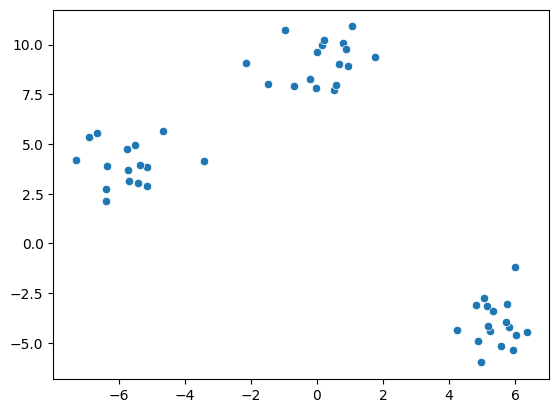

In [10]:
sns.scatterplot(x=X[:,0], y=X[:,1])

In [11]:
from scipy.cluster.hierarchy import dendrogram,linkage

In [12]:
link=linkage(X,method='ward')

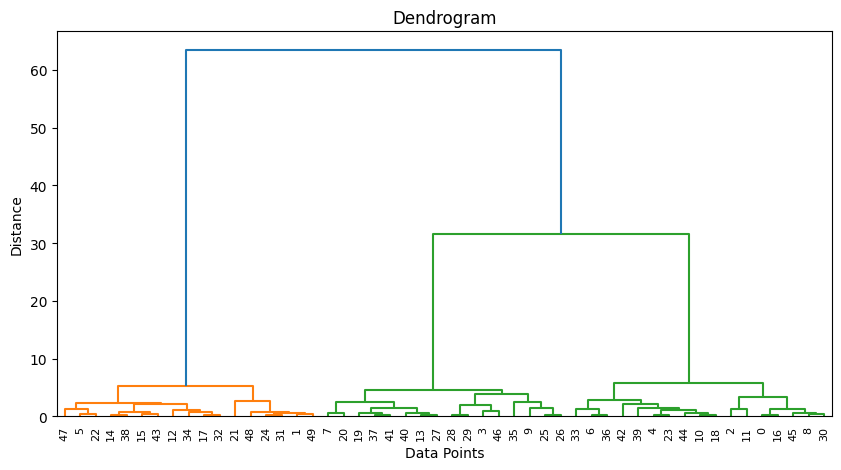

In [13]:
plt.figure(figsize=(10,5))
dendrogram(link)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [14]:
from sklearn.cluster import AgglomerativeClustering

In [15]:
algo=AgglomerativeClustering(n_clusters=3,linkage='ward')

In [16]:
algo.fit(X)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


<Axes: >

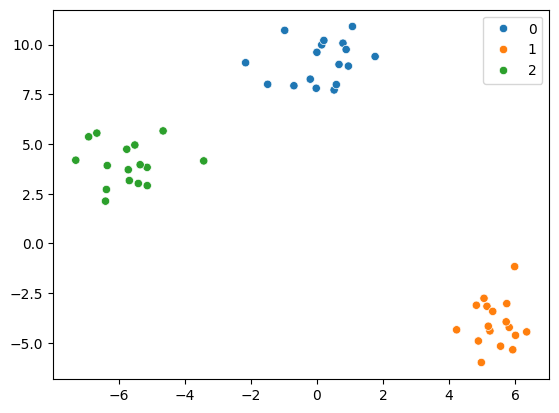

In [18]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=algo.labels_, palette='tab10')


### DBSCAN

In [19]:
from sklearn.datasets import make_blobs,make_circles,make_moons

In [20]:
non_linear=make_blobs(n_samples=1000,random_state=23)

In [24]:
sns.scatterplot(x=non_linear[:,0],y=non_linear[:,1])

TypeError: tuple indices must be integers or slices, not tuple

In [22]:
from sklearn.cluster import DBSCAN

In [ ]:
non_linear=make_blobs(n_samples=1000,random_state=23)

In [28]:
moon=make_moons(n_samples=100,random_state=23,noise=0.05)

In [29]:
sns.scatterplot(x=moon[:,0],y=moon[:,1])

TypeError: tuple indices must be integers or slices, not tuple

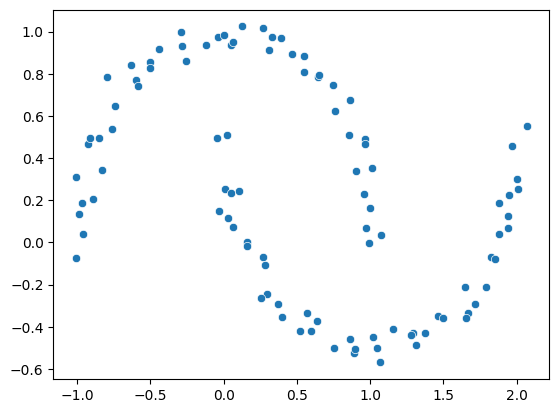

In [30]:
from sklearn.datasets import make_moons
import seaborn as sns
import matplotlib.pyplot as plt

# Correct way
X, y = make_moons(n_samples=100, noise=0.05, random_state=23)

# Plot
sns.scatterplot(x=X[:,0], y=X[:,1])
plt.show()

In [1]:
#kmeans.fit(X)
#sns.scatterplot(x=X[:,0], y=X[:,1])

In [1]:
import pandas as pd
import numpy as np

In [49]:
df=pd.read_csv(r"C:\Users\chintha kalyan\Downloads\tmdbdf.csv")
df=df.head(5000)

In [50]:
df.describe(include=object)

,title,overview,keywords,genres,poster_path
count,5000,5000,4923,5000,5000
unique,4888,5000,4900,1377,5000
top,Pinocchio,The tale of two brothers with serious financia...,duringcreditsstinger,Comedy,/hydGWxW9VvRXMwpwFacl7XVtoeR.jpg
freq,4,1,5,246,1


In [51]:
df['tags']=df['overview'].fillna(' ')+df['keywords'].fillna(' ')+df['genres'].fillna(' ')
df['tags']

0       Cobb, a skilled thief who commits corporate es...
1       The adventures of a group of explorers who mak...
2       Batman raises the stakes in his war on crime. ...
3       In the 22nd century, a paraplegic Marine is di...
4       When an unexpected enemy emerges and threatens...
                              ...                        
4995    What do you dream of when you're 16-years-old ...
4996    When his young daughter's beloved companion — ...
4997    Three years after her relationship with Giovan...
4998    Two turkeys from opposite sides of the tracks ...
4999    The tale of two brothers with serious financia...
Name: tags, Length: 5000, dtype: object

In [52]:
df['tags'].isna().sum()

np.int64(0)

### lowercase

In [53]:
df['tags']=df['tags'].apply(lambda x:x.lower())
df['tags']

0       cobb, a skilled thief who commits corporate es...
1       the adventures of a group of explorers who mak...
2       batman raises the stakes in his war on crime. ...
3       in the 22nd century, a paraplegic marine is di...
4       when an unexpected enemy emerges and threatens...
                              ...                        
4995    what do you dream of when you're 16-years-old ...
4996    when his young daughter's beloved companion — ...
4997    three years after her relationship with giovan...
4998    two turkeys from opposite sides of the tracks ...
4999    the tale of two brothers with serious financia...
Name: tags, Length: 5000, dtype: object

### Removing tags Punctiation

In [54]:
df['tags']=df['tags'].str.replace(r'[^\w\s]','',regex=True)
df['tags']

0       cobb a skilled thief who commits corporate esp...
1       the adventures of a group of explorers who mak...
2       batman raises the stakes in his war on crime w...
3       in the 22nd century a paraplegic marine is dis...
4       when an unexpected enemy emerges and threatens...
                              ...                        
4995    what do you dream of when youre 16yearsold and...
4996    when his young daughters beloved companion  an...
4997    three years after her relationship with giovan...
4998    two turkeys from opposite sides of the tracks ...
4999    the tale of two brothers with serious financia...
Name: tags, Length: 5000, dtype: object

In [55]:
#!pip install nltk

In [56]:
from nltk.stem import PorterStemmer

In [57]:
ps=PorterStemmer()

In [58]:
ps.stem('running')

'run'

In [59]:
def stemming(word):
    y=[]
    for i in word.split():
        y.append(ps.stem(i))
    return ' '.join(y)

In [60]:
df['tags']

0       cobb a skilled thief who commits corporate esp...
1       the adventures of a group of explorers who mak...
2       batman raises the stakes in his war on crime w...
3       in the 22nd century a paraplegic marine is dis...
4       when an unexpected enemy emerges and threatens...
                              ...                        
4995    what do you dream of when youre 16yearsold and...
4996    when his young daughters beloved companion  an...
4997    three years after her relationship with giovan...
4998    two turkeys from opposite sides of the tracks ...
4999    the tale of two brothers with serious financia...
Name: tags, Length: 5000, dtype: object

In [61]:
df['tags']=df['tags'].apply(stemming)
df['tags']

0       cobb a skill thief who commit corpor espionag ...
1       the adventur of a group of explor who make use...
2       batman rais the stake in hi war on crime with ...
3       in the 22nd centuri a parapleg marin is dispat...
4       when an unexpect enemi emerg and threaten glob...
                              ...                        
4995    what do you dream of when your 16yearsold and ...
4996    when hi young daughter belov companion an andr...
4997    three year after her relationship with giovann...
4998    two turkey from opposit side of the track must...
4999    the tale of two brother with seriou financi wo...
Name: tags, Length: 5000, dtype: object

### converting into vector

In [62]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [63]:
tf=TfidfVectorizer(max_features=21000,stop_words='english')

In [64]:
vector=tf.fit_transform(df['tags'])

In [65]:
tf.get_feature_names_out().tolist()

['00',
 '006',
 '007',
 '10',
 '100',
 '1000',
 '10000',
 '100000',
 '1000foot',
 '100th',
 '101',
 '10191',
 '101yearold',
 '1021',
 '108yearold',
 '10b',
 '10round',
 '10th',
 '10yearold',
 '11',
 '111',
 '1114pm',
 '1138',
 '117',
 '118th',
 '11th',
 '11year',
 '11yearold',
 '12',
 '120',
 '1200',
 '1250',
 '125000',
 '12hour',
 '12person',
 '12th',
 '12thcenturi',
 '12year',
 '12yearold',
 '13',
 '130',
 '1350',
 '13th',
 '13week',
 '13yearold',
 '14',
 '140',
 '14000',
 '1408',
 '142',
 '1429',
 '1492',
 '14th',
 '14thcenturi',
 '14yearold',
 '15',
 '150',
 '150man',
 '1536',
 '155',
 '1561',
 '15th',
 '15thcenturi',
 '15yearold',
 '16',
 '161',
 '1630',
 '1666',
 '16th',
 '16year',
 '16yearold',
 '16yearsold',
 '17',
 '1718',
 '17th',
 '17yearold',
 '18',
 '180',
 '1800',
 '1820',
 '1839',
 '1843',
 '1851',
 '1860',
 '1862',
 '1863',
 '1868',
 '1870',
 '1879',
 '1885',
 '1890',
 '1890sislandnightmareisolationmermaidhallucinationlighthouselighthousekeepergayintereststormmalemastur

### calculate the similarity

In [66]:
from sklearn.metrics.pairwise import cosine_similarity

In [67]:
similarity=cosine_similarity(vector)

In [68]:
similarity=cosine_similarity(vector)

In [69]:
similaritydf=pd.DataFrame(similarity,index=df['title'],columns=df['title'])
similaritydf

title,Inception,Interstellar,The Dark Knight,Avatar,The Avengers,Deadpool,Avengers: Infinity War,Fight Club,Guardians of the Galaxy,Pulp Fiction,...,Undisputed II: Last Man Standing,The Fan,Demon Slayer: Kimetsu no Yaiba -To the Swordsmith Village-,Prey,Sunrise: A Song of Two Humans,Summer of 85,After Yang,Like a Cat on a Highway 2,Free Birds,Cassandra's Dream
title,,,,,,,,,,,,,,,,,,,,,
Inception,1.000000,0.000000,0.005283,0.000000,0.000000,0.011080,0.009901,0.000000,0.063081,0.006176,...,0.010502,0.043590,0.012851,0.000000,0.009940,0.007204,0.022010,0.011438,0.000000,0.000000
Interstellar,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.017568,0.000000,0.017371,0.023712,...,0.000000,0.000000,0.013975,0.000000,0.000000,0.019590,0.073003,0.000000,0.027681,0.000000
The Dark Knight,0.005283,0.000000,1.000000,0.000000,0.021014,0.004767,0.004259,0.000000,0.000000,0.019966,...,0.004518,0.014150,0.027691,0.000000,0.004276,0.000000,0.005550,0.024293,0.000000,0.026877
Avatar,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.020449,0.000000,0.000000,0.000000,...,0.020129,0.010276,0.025798,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020781
The Avengers,0.000000,0.000000,0.021014,0.000000,1.000000,0.000000,0.033299,0.000000,0.000000,0.000000,...,0.000000,0.019629,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018788,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Summer of 85,0.007204,0.019590,0.000000,0.000000,0.000000,0.010181,0.008215,0.000000,0.000000,0.037598,...,0.020783,0.000000,0.000000,0.015677,0.000000,1.000000,0.007569,0.000000,0.029596,0.000000
After Yang,0.022010,0.073003,0.005550,0.000000,0.000000,0.011642,0.029980,0.014012,0.014820,0.006489,...,0.011034,0.014946,0.013502,0.000000,0.010444,0.007569,1.000000,0.027097,0.000000,0.000000
Like a Cat on a Highway 2,0.011438,0.000000,0.024293,0.000000,0.000000,0.010321,0.043935,0.000000,0.051677,0.005753,...,0.009782,0.030638,0.011970,0.000000,0.009259,0.000000,0.027097,1.000000,0.000000,0.000000


In [70]:
similaritydf['Inception'].sort_values(ascending=False)[1:6]

title
Apex                           0.115027
Four Weddings and a Funeral    0.108307
Minority Report                0.106520
The Place Beyond the Pines     0.104242
Upgrade                        0.102301
Name: Inception, dtype: float64

In [71]:
similaritydf["Avatar"].sort_values(ascending=False)[1:6]

title
Apollo 18                           0.149449
The Matrix                          0.146842
What Ever Happened to Baby Jane?    0.131648
Tears of the Sun                    0.128713
Prospect                            0.127626
Name: Avatar, dtype: float64

In [72]:
df[df['title']=='Avatar'].index[0]

np.int64(3)

In [73]:
def recommen(movie):
    idx=df[df['title']==movie].index[0]
    movie_list=np.argsort(similaritydf.iloc[idx])[::-1][1:6]
    return df.iloc[movie_list].title.tolist()

In [74]:
recommen('Avatar')           

['Apollo 18',
 'The Matrix',
 'What Ever Happened to Baby Jane?',
 'Tears of the Sun',
 'Prospect']

In [75]:
recommen('Predator')

['The Losers',
 'Predators',
 'The Pyramid',
 'Predator 2',
 'Mission: Impossible - Fallout']

In [76]:
df['poster_path']

0       /oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg
1       /gEU2QniE6E77NI6lCU6MxlNBvIx.jpg
2       /qJ2tW6WMUDux911r6m7haRef0WH.jpg
3       /kyeqWdyUXW608qlYkRqosgbbJyK.jpg
4        /RYMX2wcKCBAr24UyPD7xwmjaTn.jpg
                      ...               
4995    /rkJKDC5gYrPXQx9IqNaUhSb3beC.jpg
4996    /qjEuDeKOhA7JqaaqhLSfoS9titb.jpg
4997    /2dQ7CILvIXl1Yw0ZXtq5XYqjeqy.jpg
4998    /gnSU2wUBq2gTkBEkxY8C1d1fXAQ.jpg
4999    /hydGWxW9VvRXMwpwFacl7XVtoeR.jpg
Name: poster_path, Length: 5000, dtype: object

In [77]:
base=('https://image.tmdb.org/t/p/w500/')
print(base+ 'https://image.tmdb.org/t/p/w500/1E5baAaEse26fej7uHcjOgEE2t2.jpg')

https://image.tmdb.org/t/p/w500/https://image.tmdb.org/t/p/w500/1E5baAaEse26fej7uHcjOgEE2t2.jpg


In [78]:
import pickle
with open(r"C:\Users\chintha kalyan\Downloads\imdb\movierecomen.pkl","wb") as file:
    similarity=pickle.dump(similarity,file)

